In [3]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import sys
import os   

sys.path.append(os.path.join(os.getcwd(), '..'))
from utilities.common_functions import clean_dataframe, create_historical_dataframe
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from sklearn.metrics import r2_score


In [2]:
# Exploring with station 44013
coordinates = [42.346, -70.651]
buoy_file = 'buoy_data.nc'
nc_file = 'ERA5/Processed/era5_2019_-83_-65_37_49.nc'

In [3]:
def load_nc(nc_file):
    dataset = xr.open_dataset(nc_file)
    # Convert the dataset to a pandas DataFrame
    df = dataset.to_dataframe()
    # Reset index to move time, latitude, and longitude from index to columns
    df_reset = df.reset_index()
    return df_reset

In [4]:
def find_four_closest_points(df_reset, coordinates):
    # Compute the Euclidean distance between each point and the target
    df_reset["distance"] = np.sqrt((df_reset['latitude'] - coordinates[0])**2 + (df_reset['longitude'] - coordinates[1])**2)
    # sort the dataframe by time and distance
    df_sorted = df_reset.sort_values(by=['time', 'distance'])
    
    # keep the four first rows for each time
    df_sorted = df_sorted.groupby('time').head(4)
    return df_sorted


In [5]:
def linear_interpolation(dataset, coordinates):
    points = dataset[['latitude', 'longitude']][:4].values
    interpolated_df_value = pd.DataFrame(columns=['time','u_interp', 'v_interp', 'ssr_interp', 't2m_interp', 'd2m_interp'])
    nb_values = len(dataset)
    
    # create a matrix with the batch of 4 points with the values of u
    u_values = dataset['u10'].values
    v_values = dataset['v10'].values
    ssr_values = dataset['ssr'].values
    t2m_values = dataset['t2m'].values
    d2m_values = dataset['d2m'].values
    u_matrix = u_values[:nb_values // 4 * 4].reshape(-1, 4).T
    v_matrix = v_values[:nb_values // 4 * 4].reshape(-1, 4).T
    ssr_matrix = ssr_values[:nb_values // 4 * 4].reshape(-1, 4).T
    t2m_matrix = t2m_values[:nb_values // 4 * 4].reshape(-1, 4).T
    d2m_matrix = d2m_values[:nb_values // 4 * 4].reshape(-1, 4).T
    
    
    # Define an interpolation function
    def interpolate_column(col):
        return griddata(points, col, (coordinates[0], coordinates[1]), method='linear')

    # Apply the interpolation function to each column of the matrices
    interpolated_df_value['u_interp'] = np.apply_along_axis(interpolate_column, 0, u_matrix)
    interpolated_df_value['v_interp'] = np.apply_along_axis(interpolate_column, 0, v_matrix)
    interpolated_df_value['ssr_interp'] = np.apply_along_axis(interpolate_column, 0, ssr_matrix)
    interpolated_df_value['t2m_interp'] = np.apply_along_axis(interpolate_column, 0, t2m_matrix)
    interpolated_df_value['d2m_interp'] = np.apply_along_axis(interpolate_column, 0, d2m_matrix)
    interpolated_df_value['time'] = dataset['time'].unique()
    
    
    
    

    return interpolated_df_value
    

In [6]:
def time_interpolating_dataset(interpolate_df):
    # interpolate between two times
    start_time = interpolate_df['time'].min()
    end_time = interpolate_df['time'].max()

    # Create a time range starting at the first occurrence of `00:50`, and repeating every hour
    new_times = pd.date_range(start=start_time + pd.Timedelta(minutes=50), 
                            end=end_time + pd.Timedelta(hours=1), 
                            freq='h')

    interpolate_df.set_index('time', inplace=True)
    # Reindex the original dataframe to include new times
    df_reindexed = interpolate_df.reindex(interpolate_df.index.union(new_times))


    # Interpolate the missing values
    df_time_interpolated = df_reindexed.interpolate(method='time')
    
    return df_time_interpolated
    

In [7]:
def process_buoy_data(station_name, year):
    # Load the buoy data
    dataframe = pd.DataFrame()
    dataframe = create_historical_dataframe(station_name, year, dataframe)
    dataframe = clean_dataframe(dataframe)
    dataframe['u_velocity'] = dataframe['WDIR'].apply(lambda x: np.cos(np.radians(270 - x))) * dataframe['WSPD']
    dataframe['v_velocity'] = dataframe['WDIR'].apply(lambda x: np.sin(np.radians(270 - x))) * dataframe['WSPD']
    dataframe['ATMP'] = dataframe['ATMP'] + 273.15
    dataframe['DEWP'] = dataframe['DEWP'] + 273.15
    return dataframe

In [8]:
dataset = load_nc(nc_file)

In [32]:
dataset = find_four_closest_points(dataset, coordinates)

In [33]:
interpolate_df = linear_interpolation(dataset, coordinates)

In [34]:
df_time_interpolated = time_interpolating_dataset(interpolate_df)

In [35]:
buoy_dataframe = process_buoy_data('44013', 2019)

/Users/matteopeduto/Documents/GitHub/master_thesis/offshore-wind-forecasting/utilities/common_functions.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'data/downloaded_historical_file_{station_number}_{year}.txt', delim_whitespace=True, skiprows=1)


In [36]:
comparative_dataset = pd.merge(buoy_dataframe, df_time_interpolated, left_index=True, right_index=True, how='inner')

In [37]:
comparative_dataset

,WDIR,WSPD,GST,PRES,ATMP,DEWP,u_velocity,v_velocity,u_interp,v_interp,ssr_interp,t2m_interp,d2m_interp
2019-01-01 00:50:00,158,9.6,11.5,1023.7,276.75,274.65,-3.596223,8.900965,-2.259404,7.786121,3.599999e-12,277.158357,273.745434
2019-01-01 01:50:00,136,10.6,12.3,1021.0,277.25,274.85,-7.363379,7.625002,-4.218832,8.244022,3.599999e-12,276.649643,274.512652
2019-01-01 02:50:00,143,11.1,13.3,1019.3,277.25,275.75,-6.680147,8.864854,-3.681302,10.249026,3.599999e-12,277.084197,274.854026
2019-01-01 03:50:00,139,12.3,14.6,1017.3,277.35,276.45,-8.069526,9.282928,-4.420316,10.291170,3.599999e-12,277.214283,275.466354
2019-01-01 04:50:00,133,12.3,15.6,1014.8,278.15,277.55,-8.995651,8.388580,-5.078977,10.529627,3.599999e-12,278.307426,275.994078
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 18:50:00,330,6.9,8.4,999.3,276.25,276.25,3.450000,-5.975575,2.687589,-7.208967,7.825286e+05,277.473914,275.888071
2019-12-31 19:50:00,329,5.6,7.2,999.5,276.35,276.35,2.884213,-4.800137,4.002990,-4.972232,4.673900e+05,277.425015,275.524863
2019-12-31 20:50:00,294,4.0,5.6,1000.4,276.25,276.25,3.654182,-1.626947,4.966479,-3.297315,1.320418e+05,277.544961,275.307733
2019-12-31 21:50:00,328,3.8,5.2,999.6,276.05,275.85,2.013693,-3.222583,3.144258,-2.899629,1.466244e+04,277.276561,275.167599


In [38]:
# Correlation between ERA5 velocity and buoy velocity
correlation_u = comparative_dataset['u_velocity'].corr(comparative_dataset['u_interp'])
correlation_v = comparative_dataset['v_velocity'].corr(comparative_dataset['v_interp'])
correlation_dewp = comparative_dataset['DEWP'].corr(comparative_dataset['d2m_interp'])
correlation_t2m = comparative_dataset['ATMP'].corr(comparative_dataset['t2m_interp'])


In [9]:
def visualize_correlation(dataset, variable_1, variable_2, variable_type, correlation):
    
    
    # Visualization 1: Scatter plot with regression line
    plt.figure(figsize=(8, 6))
    sns.regplot(x=variable_1, y=variable_2, data=dataset)
    # add an x=y line
    x = np.linspace(dataset[variable_1].min(), dataset[variable_1].max(), 100)
    plt.plot(x, x, 'k--')
    plt.plot
    plt.title(f'Scatter Plot of {variable_type} (ERA5 vs Buoy) - Correlation: {correlation:.2f}')
    plt.xlabel(f'{variable_1} (ERA5)')
    plt.ylabel(f'{variable_2} (Buoy)')
    plt.show()

    # Visualization 2: Time-series comparison
    plt.figure(figsize=(10, 6))
    plt.plot(dataset.index, dataset[variable_1], label=f'ERA5 {variable_1}', marker='o')
    plt.plot(dataset.index, dataset[variable_2], label=f'Buoy {variable_2}', marker='x')
    plt.title(f'Time Series of {variable_2} vs {variable_1} (ERA5 vs Buoy)')
    plt.xlabel('Time')
    plt.ylabel(f'{variable_type}')
    plt.legend()
    plt.show()

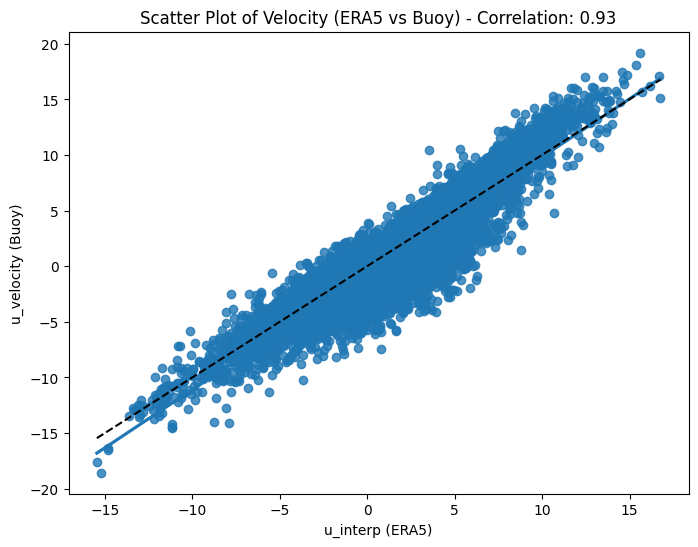

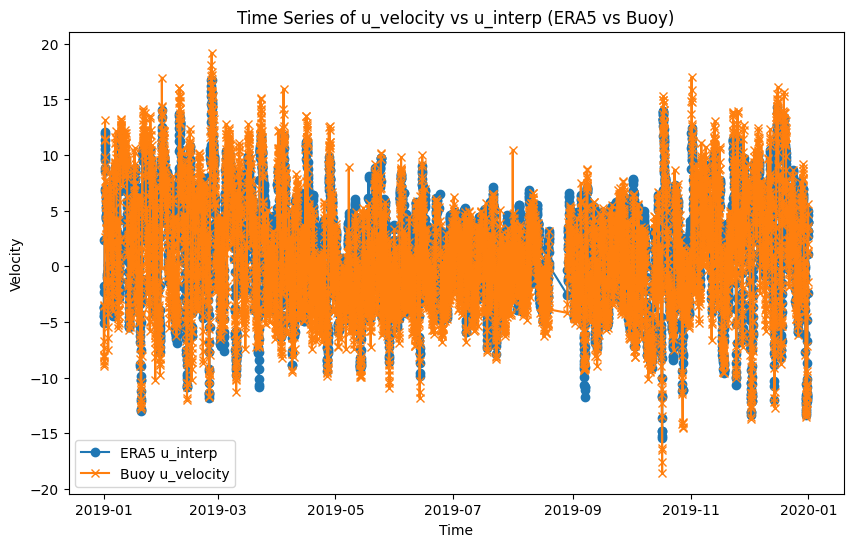

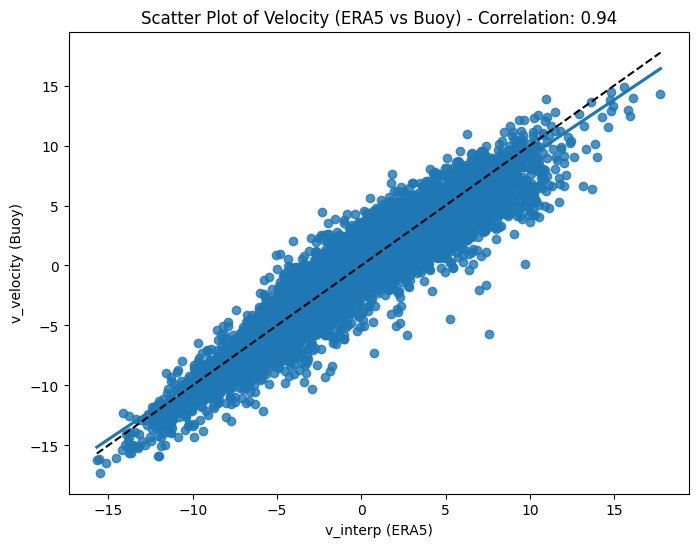

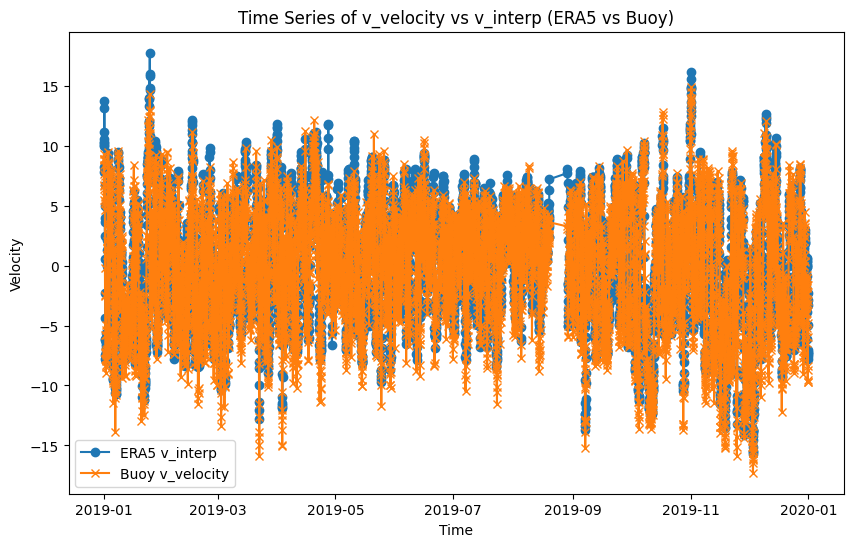

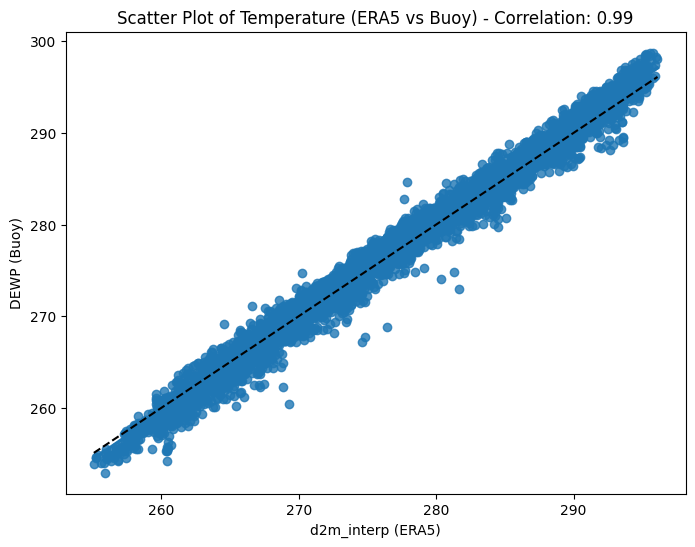

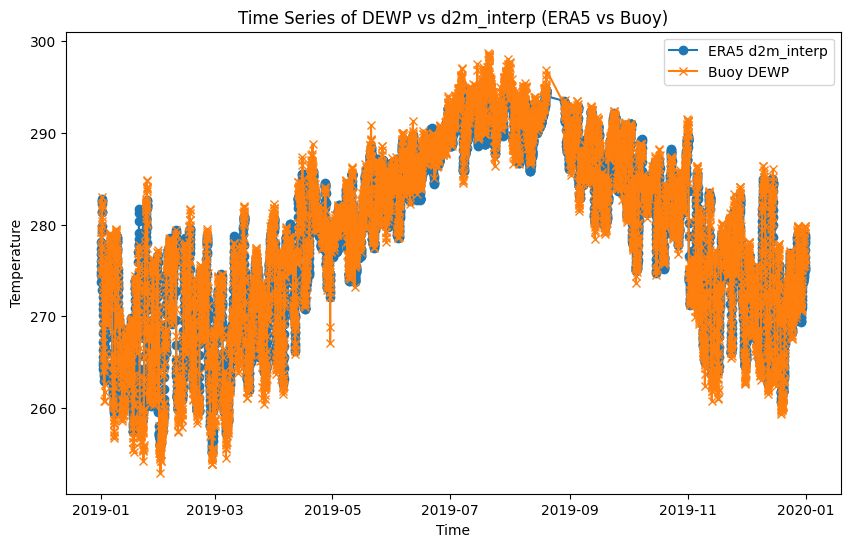

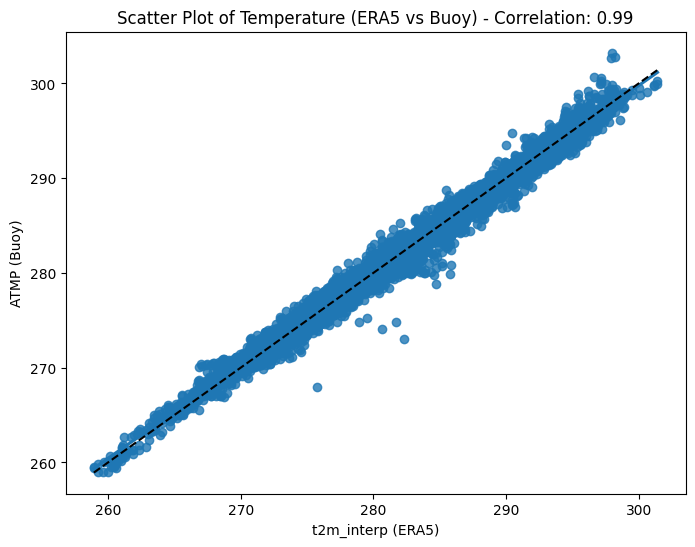

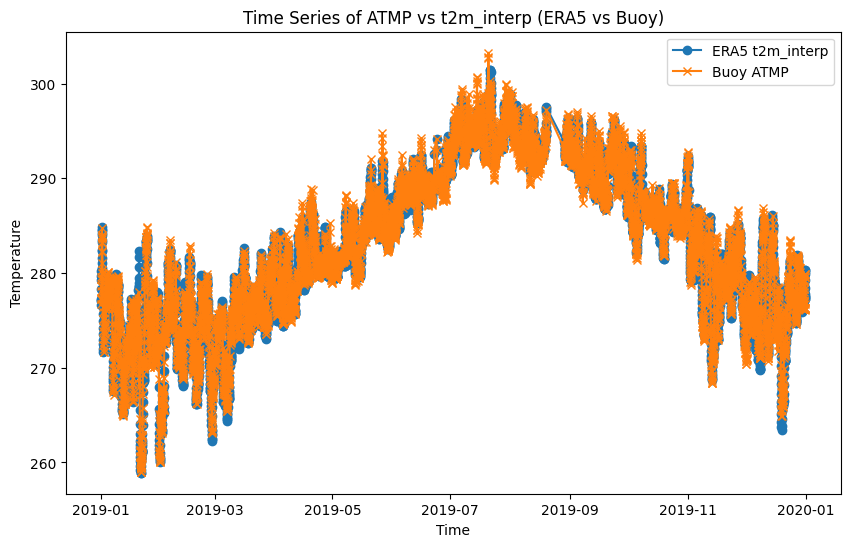

In [40]:
visualize_correlation(comparative_dataset, 'u_interp', 'u_velocity', 'Velocity', correlation_u)
visualize_correlation(comparative_dataset, 'v_interp', 'v_velocity', 'Velocity', correlation_v)
visualize_correlation(comparative_dataset, 'd2m_interp', 'DEWP', 'Temperature', correlation_dewp)
visualize_correlation(comparative_dataset, 't2m_interp', 'ATMP', 'Temperature', correlation_t2m)


In [10]:
buoy_dataframe = load_nc(buoy_file)

In [11]:
stations_list = buoy_dataframe['station_id'].unique()

In [12]:
# load geojson file
gdf = gpd.read_file('filtered_stations.geojson')

In [62]:
correlation_u = []
correlation_v = []
correlation_dewp = []
correlation_t2m = []

In [63]:
def select_closest_interpolated_time(buoy_dataframe_selected, df_time_interpolated):
    
    # slice interpolated dataframe to keep only the closest time to the buoy time
    buoy_dataframe_selected = buoy_dataframe_selected.sort_values('datetime')
    df_time_interpolated = df_time_interpolated.sort_values('time')
    
    # Use merge_asof to find the closest time
    closest_times_df = pd.merge_asof(
        buoy_dataframe_selected,
        df_time_interpolated,
        left_on='datetime',
        right_on='time',
        direction='nearest'  # Choose the closest time
    )
    

    return closest_times_df
    
    
    
    

In [64]:
stations_list_test = stations_list[: 1]

Processing station 44041 at coordinates [37.211, -76.787]


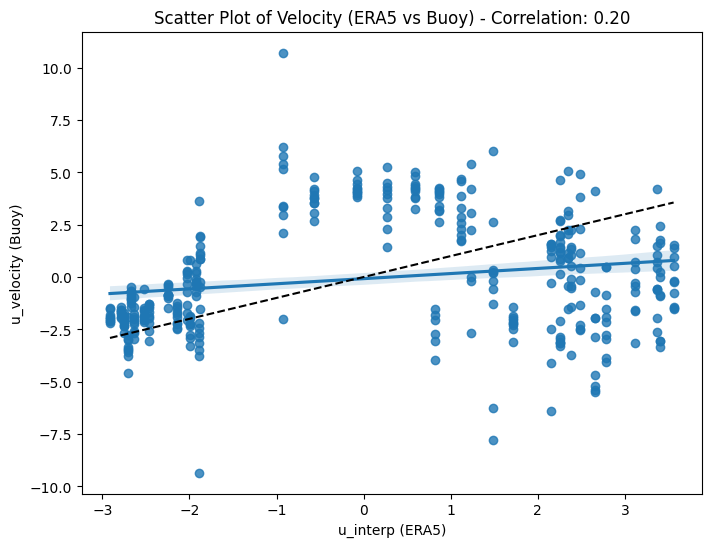

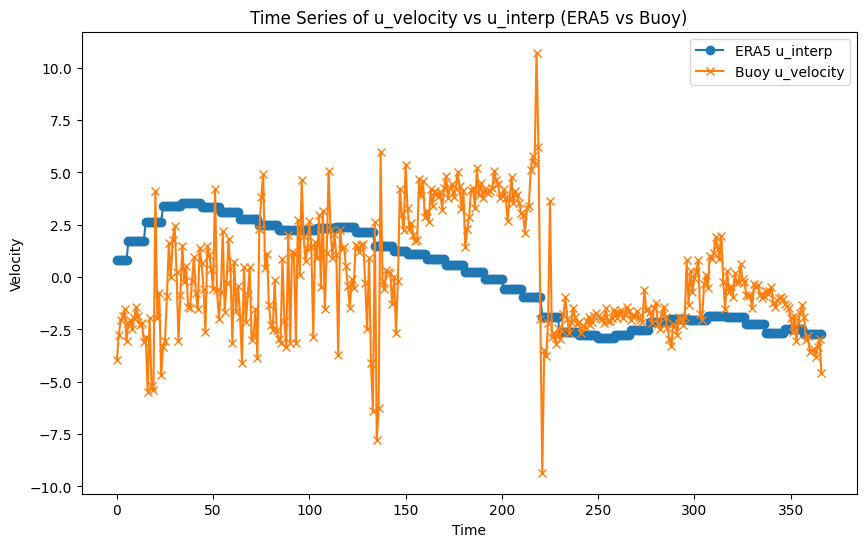

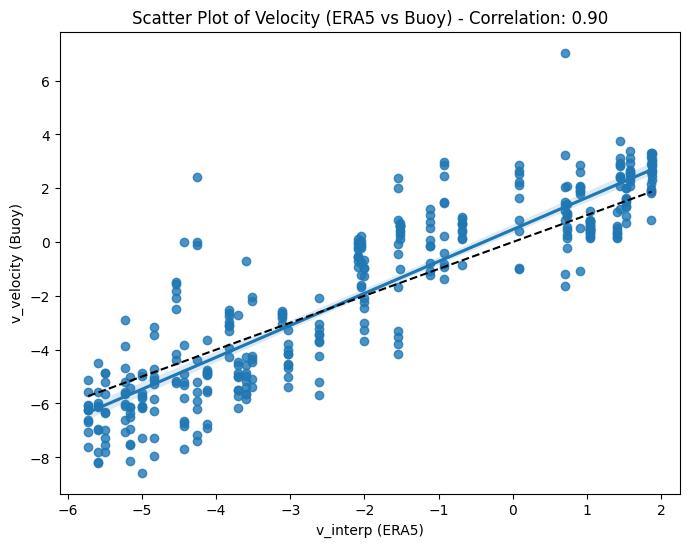

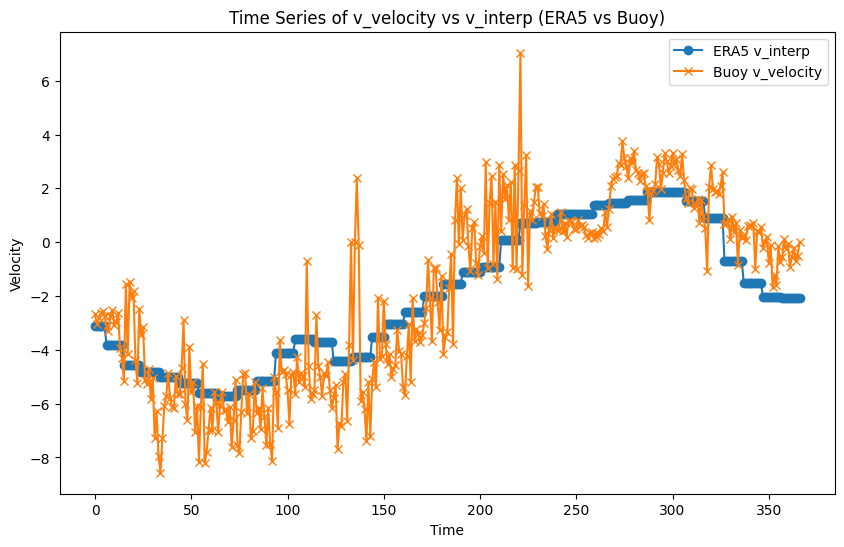

Processing station 44042 at coordinates [38.033, -76.335]


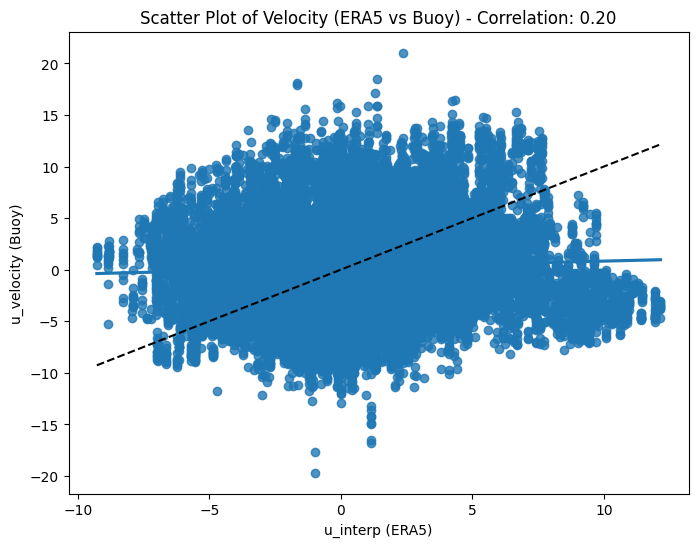

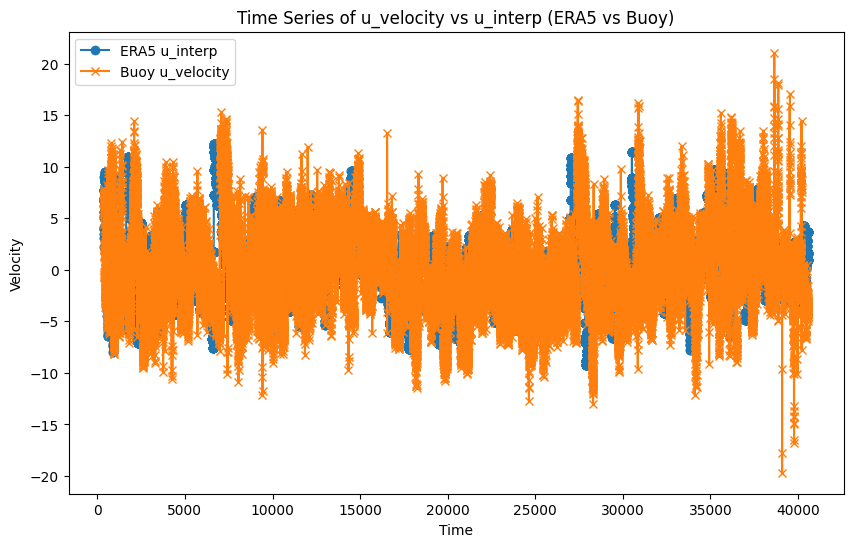

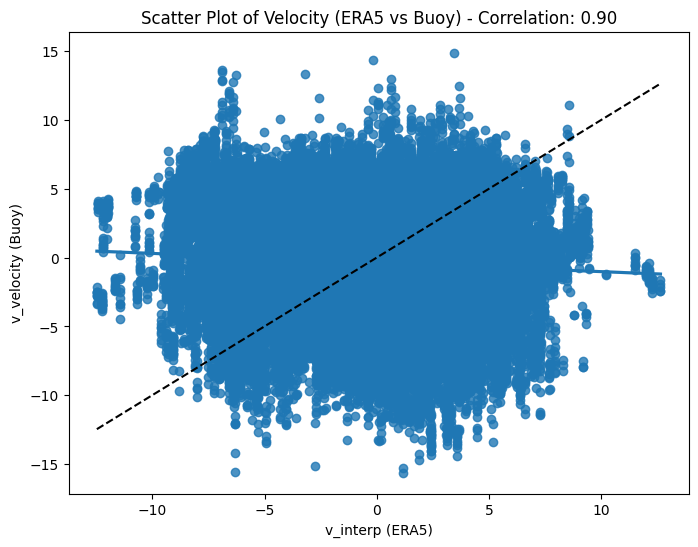

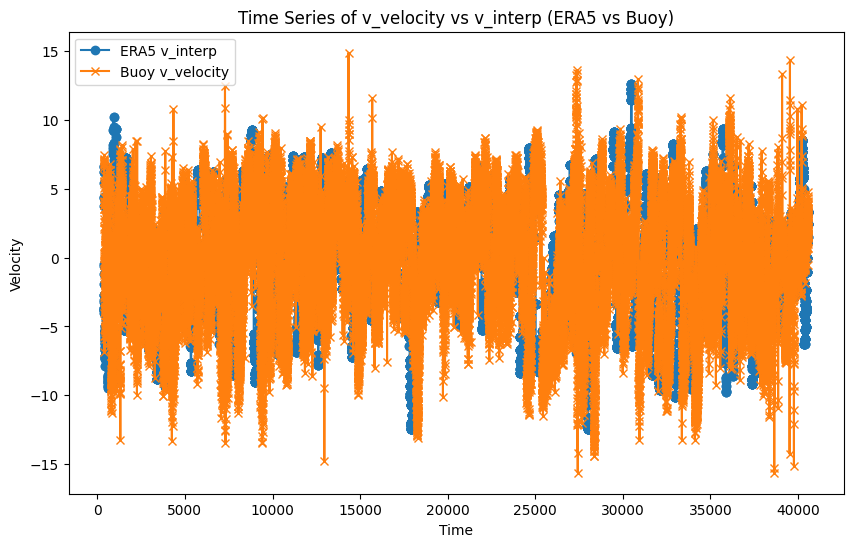

Processing station 44058 at coordinates [37.567, -76.257]


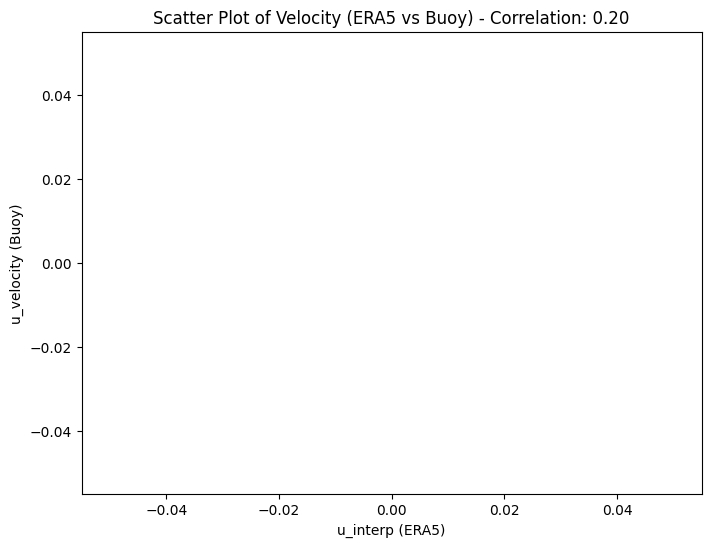

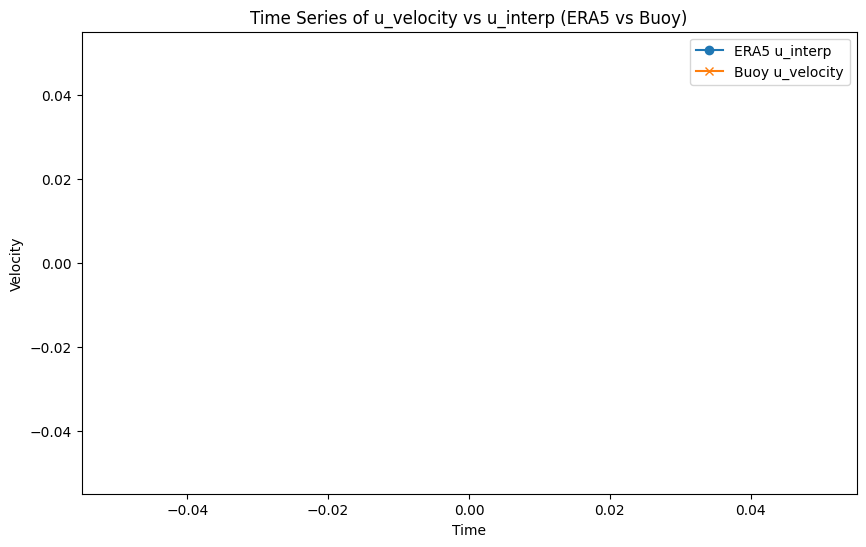

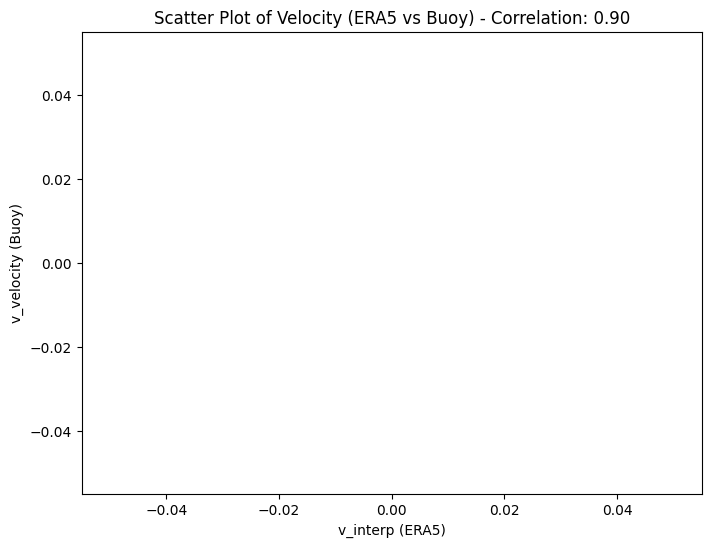

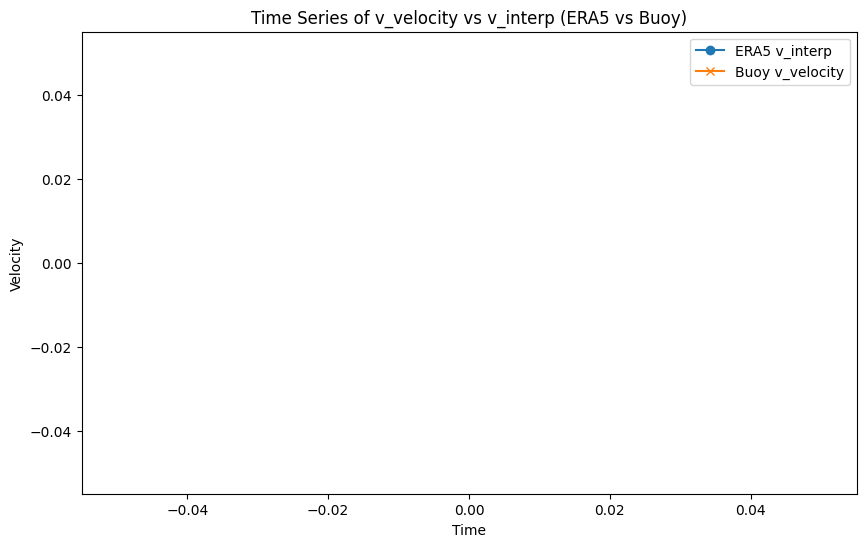

Processing station 44062 at coordinates [38.556, -76.415]


TypeError: remove: path should be string, bytes or os.PathLike, not NoneType

Exception ignored in: 'scipy._lib.messagestream.MessageStream.__dealloc__'
Traceback (most recent call last):
  File "messagestream.pyx", line 91, in scipy._lib.messagestream.MessageStream.close
TypeError: remove: path should be string, bytes or os.PathLike, not NoneType


KeyboardInterrupt: 

In [65]:
for station in stations_list:
    longitude = gdf[gdf['station'] == station]['longitude'].values[0]
    latitude = gdf[gdf['station'] == station]['latitude'].values[0]
    coordinates = [float(latitude), float(longitude)]
    buoy_dataframe_selected = buoy_dataframe[buoy_dataframe['station_id'] == station].copy()
    # print(buoy_dataframe_selected)
    print(f'Processing station {station} at coordinates {coordinates}')
    dataset_close = find_four_closest_points(dataset, coordinates)
    interpolate_df = linear_interpolation(dataset_close, coordinates)
    
    closest_times_df= select_closest_interpolated_time(buoy_dataframe_selected, interpolate_df)
    
    
    
    # print(buoy_dataframe_selected['WDIR'])
    # print(buoy_dataframe_selected['WSPD'])
    
    buoy_dataframe_selected.loc[:, 'u_velocity'] = buoy_dataframe_selected['WDIR'].apply(lambda x: np.cos(np.radians(270 - x))) * buoy_dataframe_selected['WSPD']
    buoy_dataframe_selected.loc[:, 'v_velocity'] = buoy_dataframe_selected['WDIR'].apply(lambda x: np.sin(np.radians(270 - x))) * buoy_dataframe_selected['WSPD']
    
    # if 999.0 in buoy_dataframe_selected['ATMP']:
    #     buoy_dataframe_selected_temp = buoy_dataframe_selected[buoy_dataframe_selected['ATMP'] != 999.0] 
    #     buoy_dataframe_selected_temp = buoy_dataframe_selected_temp + 273.15
    comparative_dataset = pd.merge(buoy_dataframe_selected, closest_times_df, left_index=True, right_index=True, how='inner')
    
    # print(buoy_dataframe_selected['u_velocity'])
    # print(closest_times_df['u_interp'])
    
    correlation_u.append(buoy_dataframe_selected['u_velocity'].corr(closest_times_df['u_interp']))
    correlation_v.append(buoy_dataframe_selected['v_velocity'].corr(closest_times_df['v_interp']))
    # correlation_t2m.append(buoy_dataframe_selected['temperature'].corr(closest_times_df['t2m_interp']))
    visualize_correlation(comparative_dataset, 'u_interp', 'u_velocity', 'Velocity', correlation_u[0])
    visualize_correlation(comparative_dataset, 'v_interp', 'v_velocity', 'Velocity', correlation_v[0])
    # visualize_correlation(comparative_dataset, 't2m_interp', 'temperature', 'Temperature', correlation_t2m[0])
    
    
    
    

In [57]:
buoy_dataframe_selected['ATMP']

0      999.0
1      999.0
2      999.0
3      999.0
4      999.0
       ...  
362    999.0
363    999.0
364    999.0
365    999.0
366    999.0
Name: ATMP, Length: 367, dtype: float32

In [55]:
comparative_dataset.columns

Index(['station_id_x', 'datetime_x', 'latitude_x', 'longitude_x', 'WDIR_x',
       'WSPD_x', 'GST_x', 'ATMP_x', 'u_velocity', 'v_velocity', 'temperature',
       'station_id_y', 'datetime_y', 'latitude_y', 'longitude_y', 'WDIR_y',
       'WSPD_y', 'GST_y', 'ATMP_y', 'time', 'u_interp', 'v_interp',
       'ssr_interp', 't2m_interp', 'd2m_interp'],
      dtype='object')

In [27]:
correlation_u = comparative_dataset['u_velocity'].corr(comparative_dataset['u_interp'])

In [38]:
correlation_u


[np.float64(0.19978163912544)]

In [20]:
# save the correlation values in a dataframe
correlation_df = pd.DataFrame({'station': stations_list, 'correlation_u': correlation_u, 'correlation_v': correlation_v, 'correlation_t2m': correlation_t2m})

In [22]:
# save file
correlation_df.to_csv('correlation_values.csv', index=False)

In [ ]:
file = 'A01_met_all_4c4d_7d6d_ac7a.nc'

dataframe = load_nc(file)

In [ ]:
dataframe.columns

In [ ]:
dataframe


In [ ]:
dataframe.drop(columns=['wind_2_gust', 'wind_2_gust_qc',
       'wind_2_speed', 'wind_2_speed_qc', 'wind_2_direction',
       'wind_2_direction_qc'], inplace=True)

In [ ]:
dataframe

In [ ]:
years = range(2019, 2024)

for year in years:
    nc_file_buoy = f'../data/years_dataframe/{year}_data.nc'
    nc_file_era5 = f'ERA5/Processed/era5_{year}_-83_-65_37_49.nc'
    ds_buoy = xr.open_dataset(nc_file_buoy)
    stations = ds_buoy['station_id'].values
    ds_era5 = xr.open_dataset(nc_file_era5)
    for station in stations:
        station_coords = [ds_buoy.sel(station_id=station).longitude.values, ds_buoy.sel(station_id=station).latitude.values]    

In [4]:
def load_and_process_nc_files(year: int):
    nc_file_buoy = f'../data/years_dataframe/{year}_data.nc'
    nc_file_era5 = f'../ERA5/Processed/era5_{year}_-83_-65_37_49.nc'
    ds_buoy = xr.open_dataset(nc_file_buoy)
    ds_era5 = xr.open_dataset(nc_file_era5)
    ds_era5_time_steps = ds_era5['time'].values
    ds_buoys_time_steps = ds_buoy['time'].values

    # Find common time steps
    common_time_steps = np.intersect1d(ds_era5_time_steps, ds_buoys_time_steps)


    ds_era5_filtered = ds_era5.sel(time=common_time_steps)
    ds_buoy_filtered = ds_buoy.sel(time=common_time_steps)
    
    return ds_era5_filtered, ds_buoy_filtered

In [5]:
def select_and_sort_stations(ds: xr.Dataset):
    stations = ds['station_id'].values[:2]
    return stations

In [6]:
def find_closest_points(station_coords: np.array,  latitudes: np.array, longitudes: np.array, ds: xr.Dataset):
    # Calculate absolute differences from the target
    differences_lat = np.abs(latitudes - station_coords[0]) 

    # Get indices of the two smallest differences
    closest_indices_lat = np.argsort(differences_lat)[:2]

    # Retrieve the two closest values
    closest_values_lat = latitudes[closest_indices_lat]

    difference_long = np.abs(longitudes - station_coords[1])
    closest_indices_long = np.argsort(difference_long)[:2]
    closest_values_long = longitudes[closest_indices_long]
    points = np.array([[closest_values_lat[0], closest_values_long[0]],
                        [closest_values_lat[0], closest_values_long[1]],
                        [closest_values_lat[1], closest_values_long[0]],
                        [closest_values_lat[1], closest_values_long[1]]])
    interp_point = np.array([[station_coords[0], station_coords[1]]])
    values = ds.sel(longitude=closest_values_long, latitude=closest_values_lat)
    
    return points, interp_point, values

In [7]:
def calculate_interpolate_values(points: np.array, interp_point: np.array, ds_buoy_filtered: xr.Dataset, station: str, values: xr.Dataset):
    
    def interpolate_column(col):
            return griddata(points, col, interp_point, method='linear')
        
    variables_to_interpolate = ['u10', 'v10', 'ssr', 't2m', 'd2m']  
    interpolated_values = {}
    

    # Loop over the variables
    for variable in variables_to_interpolate:
        values_variable = values[variable].values
        N = values_variable.shape[0]
        values_variables_reshaped = values_variable.reshape(N, 4)
    
        interpolated_values = np.apply_along_axis(interpolate_column, 1, values_variables_reshaped)
        
        
        
        ds_buoy_filtered[variable + '_interp'] = (('time', station), interpolated_values)
    
    return ds_buoy_filtered

In [8]:
def post_process_before_corr(ds_buoy_filtered: xr.Dataset, station: str, variable: str):
    
    if variable == 'u':
        
        buoy_data = np.array(ds_buoy_filtered.sel(station_id=station)['u_velocity'])
        interp_data = np.array(ds_buoy_filtered.sel(station_id=station)['u10_interp'])
    elif variable == 'v':
        buoy_data = np.array(ds_buoy_filtered.sel(station_id=station)['v_velocity'])
        interp_data = np.array(ds_buoy_filtered.sel(station_id=station)['v10_interp'])
    elif variable == 't':
        buoy_data = np.array(ds_buoy_filtered.sel(station_id=station)['ATMP'])
        interp_data = np.array(ds_buoy_filtered.sel(station_id=station)['t2m_interp'])
    else:
        raise ValueError('Invalid correlation type')
    
    nan_idx = np.isnan(buoy_data)
    buoy_data = buoy_data[~nan_idx]
    interp_data = interp_data[~nan_idx]
    
    return buoy_data, interp_data
    
    

In [9]:
years = [2019]
correlation_u = {'2019': [], '2020': [], '2021': [], '2022': [], '2023': []}
correlation_v = {'2019': [], '2020': [], '2021': [], '2022': [], '2023': []}
correlation_t2m = {'2019': [], '2020': [], '2021': [], '2022': [], '2023': []}
ds_buoy_filtered_dict = {'2019': xr.Dataset, '2020': xr.Dataset, '2021': xr.Dataset, '2022': xr.Dataset, '2023': xr.Dataset}
ds_era5_filtered_dict = {'2019': xr.Dataset, '2020': xr.Dataset, '2021': xr.Dataset, '2022': xr.Dataset, '2023': xr.Dataset} 
stations_dict = {'2019': [], '2020': [], '2021': [], '2022': [], '2023': []} 


In [10]:
for year in years:
    ds_era5_filtered, ds_buoy_filtered = load_and_process_nc_files(year)
    latitudes = np.array(ds_era5_filtered['latitude'])
    longitudes = np.array(ds_era5_filtered['longitude'])
    stations = select_and_sort_stations(ds_buoy_filtered)
    
    for i, station in enumerate(stations):
        
        station_coords = [float(ds_buoy_filtered.sel(station_id=station).latitude.values), float(ds_buoy_filtered.sel(station_id=station).longitude.values)] 

        points, interp_point, values = find_closest_points(station_coords, latitudes, longitudes, ds_era5_filtered)
        
        
        ds_buoy_filtered = calculate_interpolate_values(points, interp_point, ds_buoy_filtered, station, values)
        
    ds_era5_filtered_dict[str(year)], ds_buoy_filtered_dict[str(year)] = ds_era5_filtered, ds_buoy_filtered
    stations_dict[str(year)] = stations
    
    
    
    


In [11]:
def calculate_proximity(proximity_type: str, buoy_data: np.array, interpolated_data: np.array, ax_: plt.Axes ):
    if proximity_type == 'correlation':
        value = np.corrcoef(buoy_data, buoy_data[:, 0])[0, 1]
        sns.regplot(x=buoy_data,y=interpolated_data , ax=ax_)
        ax_.set_title(f'Correlation for {station} with a correlation: {value:.2f}')
        
    elif proximity_type == 'time_series':
        ax_.plot(buoy_data, label='Buoy Data')
        ax_.plot(interpolated_data, label='Interpolated Data')
        ax_.set_title(f'Time Series for {station}')
        ax_.legend()
        value = None
    elif proximity_type == 'r2':
        value = r2_score(buoy_data, interpolated_data)
        sns.regplot(x=buoy_data, y=interpolated_data, ax=ax_)
        ax_.set_title(f'R2 Score for {station} with a score: {value:.2f}')      
    else:
        raise ValueError('Invalid proximity type')
    
    return value
    
    

In [14]:
def visualize_correlation_variables(stations: list, ds_buoy_filtered: xr.Dataset, variable: str, proximity: str):
       
    n_cols = 3
    n_rows = (len(stations) // n_cols) + (len(stations) % n_cols > 0)

    # Create a figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()  # Flatten the axes array for easy indexing  
    similarity_values = []    
    for i, station in enumerate(stations):    
        
        
        buoy_data, interp_data = post_process_before_corr(ds_buoy_filtered, station, variable)
        value_similarity = calculate_proximity(proximity, buoy_data, interp_data, axes[i])
        similarity_values.append(value_similarity)
        
        
        
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()  # Adjust layout
    plt.show()
    
    return similarity_values
    

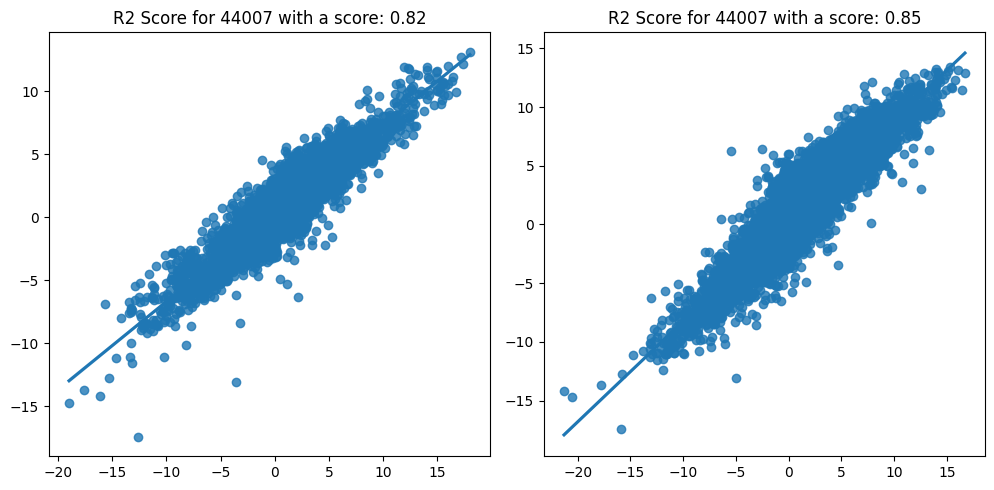

In [15]:
year = 2019
stations = stations_dict[str(year)]
proximity = visualize_correlation_variables(stations, ds_buoy_filtered_dict[str(year)], 'u', 'r2') 

In [ ]:
def visualize_correlation_variables(stations: list, ds_buoy_filtered: xr.Dataset, year: int):
       
    n_cols = 3
    n_rows = (len(stations) // n_cols) + (len(stations) % n_cols > 0)

    # Create a figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()  # Flatten the axes array for easy indexing    
    for i, station in enumerate(stations):    
        u_velocity = np.array(ds_buoy_filtered.sel(station_id=station)['u_velocity'])
        u10_interp = np.array(ds_buoy_filtered.sel(station_id=station)['u10_interp'])
        v_velocity = np.array(ds_buoy_filtered.sel(station_id=station)['v_velocity'])
        v10_interp = np.array(ds_buoy_filtered.sel(station_id=station)['v10_interp'])
        temperature = np.array(ds_buoy_filtered.sel(station_id=station)['ATMP'])
        t2m_interp = np.array(ds_buoy_filtered.sel(station_id=station)['t2m_interp'])
        nan_idx_u = np.isnan(u_velocity)
        u_velocity = u_velocity[~nan_idx_u]   
        u10_interp = u10_interp[~nan_idx_u]
        nan_idx_v = np.isnan(v_velocity)
        v_velocity = v_velocity[~nan_idx_v]
        v10_interp = v10_interp[~nan_idx_v]
        nan_idx_t = np.isnan(temperature)
        temperature = temperature[~nan_idx_t]
        t2m_interp = t2m_interp[~nan_idx_t]
        
        
        u_correlation_station = np.corrcoef(u_velocity, u10_interp[:, 0])[0, 1]
        v_correlation_station = np.corrcoef(v_velocity, v10_interp[:, 0])[0, 1]
        t_correlation_station = np.corrcoef(temperature, t2m_interp[:, 0])[0, 1]
        correlation_u[str(year)].append(u_correlation_station)
        correlation_v[str(year)].append(v_correlation_station)
        correlation_t2m[str(year)].append(t_correlation_station)
        
        sns.regplot(x=u_velocity,y=u10_interp , ax=axes[i])
        axes[i].set_title(f'Correlation for {station} with a correlation: {u_correlation_station:.2f}')
        
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()  # Adjust layout
    plt.show()
    

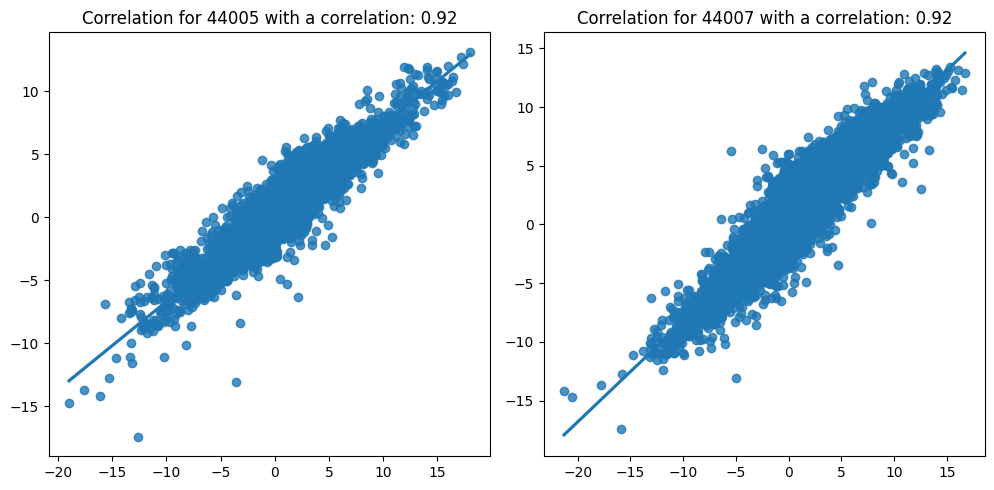

In [39]:
stations = stations_dict[str(year)]   
n_cols = 3
n_rows = (len(stations) // n_cols) + (len(stations) % n_cols > 0)

# Create a figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # Flatten the axes array for easy indexing    
for i, station in enumerate(stations):    
    u_velocity = np.array(ds_buoy_filtered.sel(station_id=station)['u_velocity'])
    u10_interp = np.array(ds_buoy_filtered.sel(station_id=station)['u10_interp'])
    v_velocity = np.array(ds_buoy_filtered.sel(station_id=station)['v_velocity'])
    v10_interp = np.array(ds_buoy_filtered.sel(station_id=station)['v10_interp'])
    temperature = np.array(ds_buoy_filtered.sel(station_id=station)['ATMP'])
    t2m_interp = np.array(ds_buoy_filtered.sel(station_id=station)['t2m_interp'])
    nan_idx_u = np.isnan(u_velocity)
    u_velocity = u_velocity[~nan_idx_u]   
    u10_interp = u10_interp[~nan_idx_u]
    nan_idx_v = np.isnan(v_velocity)
    v_velocity = v_velocity[~nan_idx_v]
    v10_interp = v10_interp[~nan_idx_v]
    nan_idx_t = np.isnan(temperature)
    temperature = temperature[~nan_idx_t]
    t2m_interp = t2m_interp[~nan_idx_t]
    
    
    u_correlation_station = np.corrcoef(u_velocity, u10_interp[:, 0])[0, 1]
    v_correlation_station = np.corrcoef(v_velocity, v10_interp[:, 0])[0, 1]
    t_correlation_station = np.corrcoef(temperature, t2m_interp[:, 0])[0, 1]
    correlation_u[str(year)].append(u_correlation_station)
    correlation_v[str(year)].append(v_correlation_station)
    correlation_t2m[str(year)].append(t_correlation_station)
    
    sns.regplot(x=u_velocity,y=u10_interp , ax=axes[i])
    axes[i].set_title(f'Correlation for {station} with a correlation: {u_correlation_station:.2f}')
    
# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  # Adjust layout
plt.show()

(4688,)
(4688, 1)
(8654,)
(8654, 1)
(5609,)
(5609, 1)
(5629,)
(5629, 1)
(2972,)
(2972, 1)
(8379,)
(8379, 1)
(5550,)
(5550, 1)
(8659,)
(8659, 1)
(6420,)
(6420, 1)
(3239,)
(3239, 1)


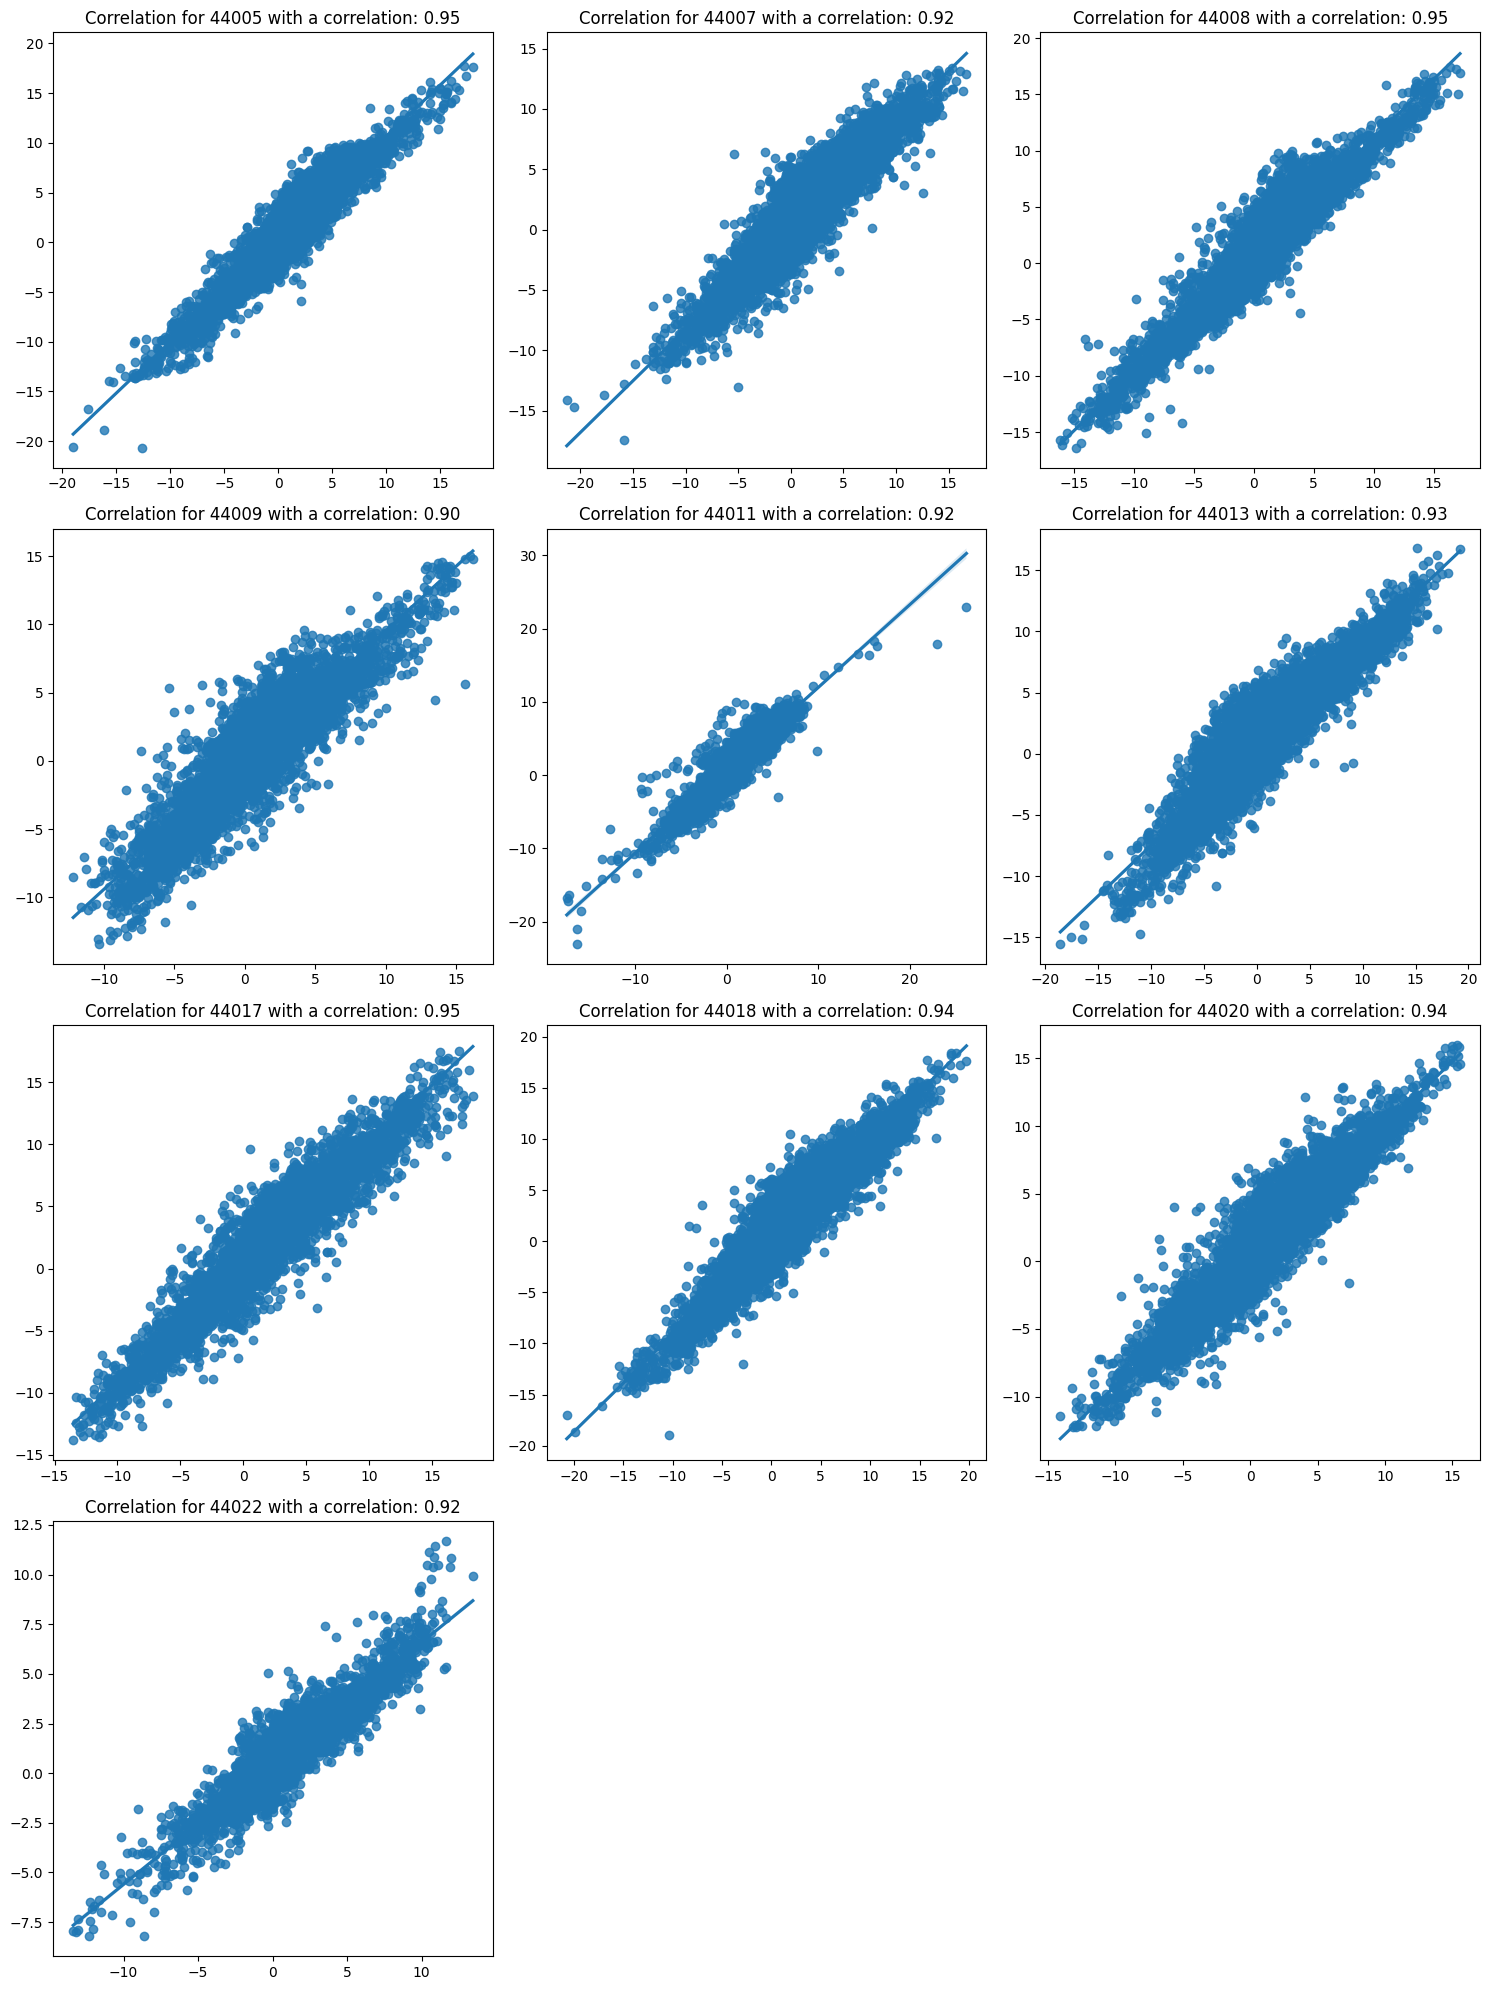

In [22]:
# Define the layout of the subplots (e.g., 3 columns)
n_cols = 3
n_rows = (len(stations) // n_cols) + (len(stations) % n_cols > 0)

# Create a figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # Flatten the axes array for easy indexing
for i, station in enumerate(stations):
    station_coords = [float(ds_buoy_filtered.sel(station_id=station).latitude.values), float(ds_buoy_filtered.sel(station_id=station).longitude.values)] 
    # Calculate absolute differences from the target
    differences_lat = np.abs(latitudes - station_coords[0]) 

    # Get indices of the two smallest differences
    closest_indices_lat = np.argsort(differences_lat)[:2]

    # Retrieve the two closest values
    closest_values_lat = latitudes[closest_indices_lat]

    difference_long = np.abs(longitudes - station_coords[1])
    closest_indices_long = np.argsort(difference_long)[:2]
    closest_values_long = longitudes[closest_indices_long]
    points = np.array([[closest_values_lat[0], closest_values_long[0]],
                        [closest_values_lat[0], closest_values_long[1]],
                        [closest_values_lat[1], closest_values_long[0]],
                        [closest_values_lat[1], closest_values_long[1]]])
    interp_point = np.array([[station_coords[0], station_coords[1]]])
    
    def interpolate_column(col):
        return griddata(points, col, interp_point, method='linear')
    variables_to_interpolate = ['u10', 'v10', 'ssr', 't2m', 'd2m']  

    # Create a dictionary to store the interpolated values
    interpolated_values = {}

    # Loop over the variables
    for variable in variables_to_interpolate:
        # Extract the variable values
        values = ds_era5_filtered.sel(longitude=closest_values_long, latitude=closest_values_lat)[variable].values

        N = values.shape[0]
        values_reshaped = values.reshape(N, 4)
    
        interpolated_values = np.apply_along_axis(interpolate_column, 1, values_reshaped)
        
        
        
        ds_buoy_filtered[variable + '_interp'] = (('time', station), interpolated_values)
    
    u_velocity = np.array(ds_buoy_filtered.sel(station_id=station)['u_velocity'])
    u10_interp = np.array(ds_buoy_filtered.sel(station_id=station)['u10_interp'])
    v_velocity = np.array(ds_buoy_filtered.sel(station_id=station)['v_velocity'])
    v10_interp = np.array(ds_buoy_filtered.sel(station_id=station)['v10_interp'])
    temperature = np.array(ds_buoy_filtered.sel(station_id=station)['ATMP'])
    t2m_interp = np.array(ds_buoy_filtered.sel(station_id=station)['t2m_interp'])
    nan_idx_u = np.isnan(u_velocity)
    u_velocity = u_velocity[~nan_idx_u]   
    u10_interp = u10_interp[~nan_idx_u]
    nan_idx_v = np.isnan(v_velocity)
    v_velocity = v_velocity[~nan_idx_v]
    v10_interp = v10_interp[~nan_idx_v]
    nan_idx_t = np.isnan(temperature)
    temperature = temperature[~nan_idx_t]
    t2m_interp = t2m_interp[~nan_idx_t]
    
    
    u_correlation_station = np.corrcoef(u_velocity, u10_interp[:, 0])[0, 1]
    v_correlation_station = np.corrcoef(v_velocity, v10_interp[:, 0])[0, 1]
    t_correlation_station = np.corrcoef(temperature, t2m_interp[:, 0])[0, 1]
    correlation_u[str(year)].append(u_correlation_station)
    correlation_v[str(year)].append(v_correlation_station)
    correlation_t2m[str(year)].append(t_correlation_station)
    
    sns.regplot(x=u_velocity,y=u10_interp , ax=axes[i])
    axes[i].set_title(f'Correlation for {station} with a correlation: {u_correlation_station:.2f}')
    
# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  # Adjust layout
plt.show()
    
    
    
    

In [10]:
station = stations[0]

In [11]:
station_coords = [float(ds_buoy_filtered.sel(station_id=station).latitude.values), float(ds_buoy_filtered.sel(station_id=station).longitude.values)] 

In [12]:
station_coords

[43.201, -69.127]

In [13]:
latitudes = ds_era5_filtered['latitude']
longitudes = ds_era5_filtered['longitude']

In [18]:
latitudes

array([49.  , 48.75, 48.5 , 48.25, 48.  , 47.75, 47.5 , 47.25, 47.  ,
       46.75, 46.5 , 46.25, 46.  , 45.75, 45.5 , 45.25, 45.  , 44.75,
       44.5 , 44.25, 44.  , 43.75, 43.5 , 43.25, 43.  , 42.75, 42.5 ,
       42.25, 42.  , 41.75, 41.5 , 41.25, 41.  , 40.75, 40.5 , 40.25,
       40.  , 39.75, 39.5 , 39.25, 39.  , 38.75, 38.5 , 38.25, 38.  ,
       37.75, 37.5 , 37.25, 37.  ])

In [20]:
# find the two closest latitudes and longitudes to the station coordinates
latitudes = np.array(latitudes)
longitudes = np.array(longitudes)

# Calculate absolute differences from the target
differences_lat = np.abs(latitudes - station_coords[0]) 

# Get indices of the two smallest differences
closest_indices_lat = np.argsort(differences_lat)[:2]

# Retrieve the two closest values
closest_values_lat = latitudes[closest_indices_lat]

difference_long = np.abs(longitudes - station_coords[1])
closest_indices_long = np.argsort(difference_long)[:2]
closest_values_long = longitudes[closest_indices_long]
points = np.array([[closest_values_lat[0], closest_values_long[0]],
                       [closest_values_lat[0], closest_values_long[1]],
                       [closest_values_lat[1], closest_values_long[0]],
                       [closest_values_lat[1], closest_values_long[1]]])
interp_point = np.array([[station_coords[0], station_coords[1]]])

def interpolate_column(col):
        return griddata(points, col, interp_point, method='linear')




variables_to_interpolate = ['u10', 'v10', 'ssr', 't2m', 'd2m']  

# Create a dictionary to store the interpolated values
interpolated_values = {}

# Loop over the variables
for variable in variables_to_interpolate:
    # Extract the variable values
    values = ds_era5_filtered.sel(longitude=closest_values_long, latitude=closest_values_lat)[variable].values
#     print(values)

    
    # Calculate fractional distances
    # Number of time steps
    N = values.shape[0]
    values_reshaped = values.reshape(N, 4)
 
    interpolated_values = np.apply_along_axis(interpolate_column, 1, values_reshaped)
    print(interpolated_values)
    
    
    
    ds_buoy_filtered[variable + '_interp'] = (('time', station), interpolated_values)
    
    
    

   
    
    
    


[[ 2.05906934]
 [ 1.79382617]
 [-0.21842261]
 ...
 [ 5.7466897 ]
 [ 2.67879431]
 [ 4.2295769 ]]
[[ 8.27111047]
 [ 9.48174927]
 [10.37906934]
 ...
 [-9.96083105]
 [-9.45860999]
 [-6.76329968]]
[[3.59999877e-12]
 [3.59999877e-12]
 [3.59999877e-12]
 ...
 [1.17428480e+05]
 [5.95712000e+02]
 [3.59999877e-12]]
[[278.40079248]
 [278.40294702]
 [278.36724902]
 ...
 [277.74913477]
 [276.93517383]
 [276.54907617]]
[[272.8435708 ]
 [272.68459619]
 [272.81014453]
 ...
 [276.61077051]
 [275.51853711]
 [274.9226875 ]]


In [21]:
correlation_u = []
correlation_v = []

In [23]:
u_velocity = np.array(ds_buoy_filtered.sel(station_id=station)['u_velocity'])
u10_interp = np.array(ds_buoy_filtered.sel(station_id=station)['u10_interp'])
v_velocity = np.array(ds_buoy_filtered.sel(station_id=station)['v_velocity'])
v10_interp = np.array(ds_buoy_filtered.sel(station_id=station)['v10_interp'])
print(u10_interp)

[[ 2.05906934]
 [ 1.79382617]
 [-0.21842261]
 ...
 [ 5.7466897 ]
 [ 2.67879431]
 [ 4.2295769 ]]


In [15]:
correlation_u.append(ds_buoy_filtered.sel(station_id=station)['u_velocity'].corr(ds_buoy_filtered.sel(station_id=station)['u10_interp']))
correlation_v.append(ds_buoy_filtered.sel(station_id=station)['v_velocity'].corr(ds_buoy_filtered.sel(station_id=station)['v10_interp']))

AttributeError: 'DataArray' object has no attribute 'corr'

In [ ]:
# create a figure to plot the scatter plot of the correlation for each station in stations
plt.figure(figsize=(8, 6))


In [82]:
points = np.array([[50, 51], [50, 50], [51, 51], [51, 50]])
# values = np.array([[1, 2, 3, 4], [5, 6, 7, 8]])
values = np.array([[1, 2, 3, 4]])
interp_point = np.array([[50.5, 50.5]])

def interpolate_column(col):
    return griddata(points, col, interp_point, method='linear')

print('points:', points.shape)
print('values:', values.shape)  
print('interp_point:', interp_point.shape)
interp_values = np.apply_along_axis(interpolate_column, 1, values)



points: (4, 2)
values: (1, 4)
interp_point: (1, 2)


In [83]:
interp_values

array([[2.5]])